In [1]:
import os
import georaster
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.lines import Line2D
import numpy as np

from whale_gunshot_localization import config

ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2], "data_env_conn", "ctd_data")

### Experimental Site Figure

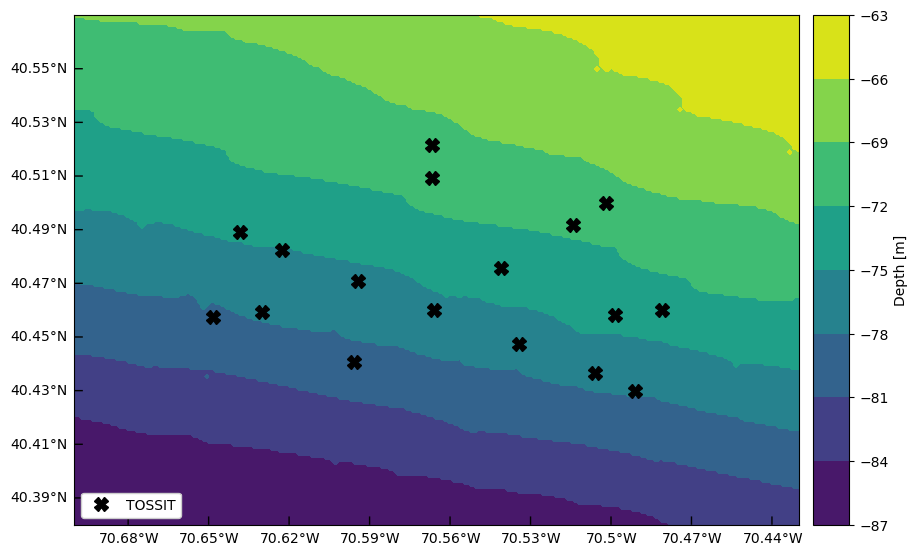

In [2]:
# buffer [in degrees]
b = 0.05

# get TOSSIT position
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
miny = np.around(TOSSIT_latlons[:,0].min(), 2)
maxy = np.around(TOSSIT_latlons[:,0].max(), 2)
minx = np.around(TOSSIT_latlons[:,1].min(), 2)
maxx = np.around(TOSSIT_latlons[:,1].max(), 2)

fig = plt.figure(figsize=(10,10))
m = Basemap(projection='cyl',
            llcrnrlon=minx-b,
            llcrnrlat=miny-b,
            urcrnrlon=maxx+b,
            urcrnrlat=maxy+b,
            resolution='i')
m.drawcoastlines(color="gray")
m.fillcontinents(color='beige')
m.drawparallels(np.arange(miny-b+0.01, maxy+b+0.01, 0.02), labels=[1, 0, 0, 0], fontsize=10, color="k", dashes=[6,1000])
m.drawmeridians(np.arange(minx-b+0.02, maxx+b+0.02, 0.03), labels=[0, 0, 0, 1], fontsize=10, color="k", dashes=[6,1000])

# load the geotiff image, assign it a variable
image = georaster.SingleBandRaster(os.path.join(config['dataset']['data_directory'], 'mikesbathym.tif'),
                                   load_data=(minx-b, maxx+b, miny-b, maxy+b),
                                   latlon=True)

# plot bathymetry
# plt.imshow(-1*image.r, extent=(minx-b, maxx+b, miny-b, maxy+b), zorder=1)
x = np.linspace(m.llcrnrx, m.urcrnrx, image.r.shape[1])
y = np.linspace(m.llcrnry, m.urcrnry, image.r.shape[0])
xx, yy = np.meshgrid(x, y)
m.contourf(xx, yy, np.flip(-1*image.r, axis=0), levels=8)

# plot sensors
m.plot(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0], 'kX', markersize=10, label="TOSSIT")

# plot colorbar and legend
m.colorbar(location='right', label='Depth [m]')
plt.legend(framealpha=1.0, loc='lower left')

plt.show()

### CTDs

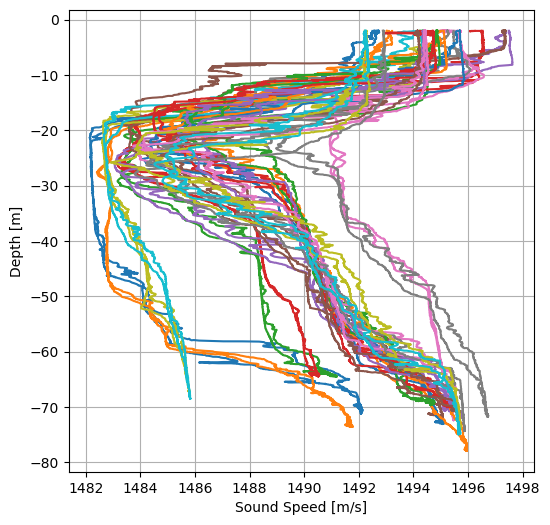

In [3]:
CTD = [11, 33]
D_min = 2
D_max = 80

fig = plt.figure(figsize=(6,6))
CTD_dict = dict()
for c, i in enumerate(range(CTD[0], CTD[1]+1)):
    
    # get date
    with open(os.path.join("/", ccb_data_root, f"CTD{i}.hdr"), "r") as f:
        for _ in range(8):
            next(f)
        line = f.readlines()[0].split(' = ')[-1].rstrip("\n")
        day = int(line[4:6])
    
    # grab data
    with open(os.path.join("/", ccb_data_root, f"CTD{i}.asc"), "r") as f:
        next(f)
        lines = f.readlines()
        for cc, line in enumerate(lines):
            if cc == 0:
                A = np.asarray([[x.rstrip("\n") for x in line.split(' ') if len(x)]], dtype=float)
            else:
                A = np.concatenate((A, np.asarray([[x.rstrip("\n") for x in line.split(' ') if len(x)]], dtype=float)), axis=0)

    if A[:,0].max() > D_max:
        continue
    A = A[np.where((A[:,0] > D_min))[0],:]
    
    # add to plot
    plt.plot(A[:,-1], -A[:,0])
    
# labels
plt.xlabel("Sound Speed [m/s]")
plt.ylabel("Depth [m]")
plt.grid()

plt.show()

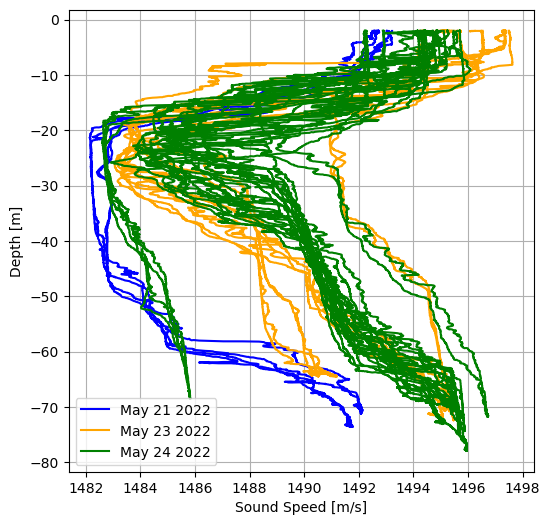

In [7]:
CTD = [11, 33]
D_min = 2
D_max = 80
colors = {21: "blue", 
          22: "black",
          23: "orange",
          24: "green"}
seen = dict([(i, False) for i in range(21,25)])

fig = plt.figure(figsize=(6,6))
CTD_dict = dict()
for c, i in enumerate(range(CTD[0], CTD[1]+1)):
    
    # get date
    with open(os.path.join("/", ccb_data_root, f"CTD{i}.hdr"), "r") as f:
        for _ in range(8):
            next(f)
        line = f.readlines()[0].split(' = ')[-1].rstrip("\n")
        day = int(line[4:6])
        date = line[:11]
    
    # grab data
    with open(os.path.join("/", ccb_data_root, f"CTD{i}.asc"), "r") as f:
        next(f)
        lines = f.readlines()
        for cc, line in enumerate(lines):
            if cc == 0:
                A = np.asarray([[x.rstrip("\n") for x in line.split(' ') if len(x)]], dtype=float)
            else:
                A = np.concatenate((A, np.asarray([[x.rstrip("\n") for x in line.split(' ') if len(x)]], dtype=float)), axis=0)

    if A[:,0].max() > D_max:
        continue
    A = A[np.where((A[:,0] > D_min))[0],:]
    
    # add to plot
    plt.plot(A[:,-1], -A[:,0], color=colors[day], label=date if not seen[day] else None)
    seen[day] = True
    
# labels
plt.xlabel("Sound Speed [m/s]")
plt.ylabel("Depth [m]")
plt.grid()
plt.legend()

plt.show()